# Datathon Passos Mágicos — Modelo preditivo de risco de defasagem (Pergunta 9)

**Desenho early-warning t→t+1:** prever se o aluno estará **defasado no ano seguinte**
(`defasagem < 0`, ≡ IAN ≤ 5) a partir dos indicadores do ano corrente.

Decisões metodológicas (justificadas em `planning/plano_modelagem_analise.md`):
- **Anti-vazamento**: o alvo é o status do ano t+1; `defasagem`/indicadores do ano t são
  preditores legítimos do risco futuro (o IAN do ano t fica fora só por ser função
  determinística de `defasagem`). Nunca se usa informação do ano-alvo.
- **Split por aluno** (`GroupShuffleSplit`): o mesmo aluno nunca aparece em treino e
  teste — evita métrica inflada por memorização.
- **Três modelos**: Regressão Logística (baseline) → RandomForest → **rede neural
  (Keras/TensorFlow)**, atendendo ao tema Deep Learning da Fase 5.
- Métricas para alvo ~balanceado (52%): acurácia, precisão, recall, F1, ROC-AUC e PR-AUC —
  e recall no subgrupo crítico (alunos **em dia** no ano t que se defasam em t+1).


In [1]:
import json
import warnings
warnings.filterwarnings('ignore')

import joblib
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, confusion_matrix,
                             roc_curve)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import tensorflow as tf
from tensorflow import keras

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)
# Paleta da marca pessoal, a mesma do dashboard e do 02_eda. Ordem categórica fixa (âmbar e coral nunca
# adjacentes, ΔE 11,9 entre si). A matriz de confusão usa rampa sequencial de um matiz só — magnitude, não
# identidade — indo do off-white da marca ao azul profundo.
CORES_MARCA = ['#1F3A5F', '#E0A458', '#2F6F73', '#DF745C', '#4C6A92', '#9AA5B1']
AZUL, AMBAR, TEAL, CORAL, CINZA = '#1F3A5F', '#E0A458', '#2F6F73', '#DF745C', '#9AA5B1'
ESCALA_MATRIZ = ['#F5F7FA', '#4C6A92', '#1F3A5F']
FUNDO, GRADE = '#F5F7FA', 'rgba(154, 165, 177, 0.35)'  # off-white da marca; grade que recua

# plotly_mimetype rende o gráfico interativo no Jupyter/PyCharm; png é o fallback estático, porque o GitHub
# não executa JavaScript ao exibir um .ipynb e sem ele os gráficos ficariam em branco no repositório. O
# fallback depende de kaleido + Chrome (`plotly_get_chrome`); sem eles o notebook roda igual, só sem png.
try:
    pio.to_image(go.Figure(), format='png')
    pio.renderers.default = 'plotly_mimetype+png'
except Exception:
    pio.renderers.default = 'plotly_mimetype'


def aplicar_marca(fig, altura=430):
    """Identidade visual da marca sobre o gráfico Plotly: superfície off-white presa na própria figura (o
    notebook não tem tema por trás para fornecê-la, e sem isso o tema escuro da IDE repinta o fundo),
    tipografia na tinta da marca e grade em Cool Gray translúcido — a grade recua, quem salta são as
    marcas de dados."""
    fig.update_layout(paper_bgcolor=FUNDO, plot_bgcolor=FUNDO, font_color=AZUL, title_font_color=AZUL,
                      legend_title_font_color=AZUL, height=altura,
                      margin=dict(l=70, r=30, t=60, b=55))
    fig.update_xaxes(gridcolor=GRADE, linecolor=GRADE, zerolinecolor=GRADE)
    fig.update_yaxes(gridcolor=GRADE, linecolor=GRADE, zerolinecolor=GRADE)
    return fig

base = pd.read_csv('../data/processed/base_risco.csv')
base['alvo'] = base['alvo_defasagem_t1'].map(lambda v: v in (True, 'True')).astype(int)
print(base.shape, '| alvo positivo:', f"{base.alvo.mean()*100:.1f}%")
base.head(3)

I0000 00:00:1785706132.732702  116138 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785706132.733455  116138 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1785706133.060651  116138 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1785706134.395777  116138 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785706134.396281  116138 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


(1290, 21) | alvo positivo: 52.0%


,id_aluno,ano,defasagem,inde,ida,ieg,iaa,ips,ipp,ipv,...,idade,tempo_vinculo,d_inde,d_ieg,d_ida,d_ipv,genero,tipo_instituicao,alvo_defasagem_t1,alvo
0,1,2022,-1.0,5.7830,4.0,4.1,8.3,5.60,8.174,7.278,...,19.0,6,NaN,NaN,NaN,NaN,Fem,Pública,False,0
1,1000,2023,0.0,7.9162,7.0,9.4,8.5,3.77,6.250,8.920,...,8.0,0,NaN,NaN,NaN,NaN,Fem,Pública,False,0
2,1001,2023,-1.0,8.1162,7.8,9.1,9.0,7.52,7.500,9.170,...,9.0,0,NaN,NaN,NaN,NaN,Fem,Pública,True,1


## 1. Features e split por aluno

In [2]:
FEATURES_NUM = ['defasagem', 'inde', 'ida', 'ieg', 'iaa_val', 'iaa_recusa', 'ips', 'ipp', 'ipv',
                'fase', 'idade', 'tempo_vinculo', 'd_inde', 'd_ieg', 'd_ida', 'd_ipv']
FEATURES_CAT = ['genero', 'tipo_instituicao']
FEATURES = FEATURES_NUM + FEATURES_CAT

X, y, grupos = base[FEATURES], base['alvo'], base['id_aluno']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
idx_tr, idx_te = next(gss.split(X, y, groups=grupos))
X_tr, X_te = X.iloc[idx_tr], X.iloc[idx_te]
y_tr, y_te = y.iloc[idx_tr], y.iloc[idx_te]
assert set(grupos.iloc[idx_tr]).isdisjoint(set(grupos.iloc[idx_te]))
print(f'treino: {len(X_tr)} ({y_tr.mean()*100:.1f}% pos) | teste: {len(X_te)} ({y_te.mean()*100:.1f}% pos)')
print('alunos treino/teste:', grupos.iloc[idx_tr].nunique(), '/', grupos.iloc[idx_te].nunique())

# NaN esperados: d_* (sem ano anterior), ipp (fase 8) e iaa_val (recusa de autoavaliação, P4 do EDA)
# -> mediana no pipeline; a recusa em si não se perde, viaja em iaa_recusa. Nas categóricas não há
# imputação: o NaN de tipo_instituicao é anomalia (abandono, EM concluído ou dado ausente) rara demais
# para virar categoria, então as categorias são fixadas e tudo fora delas (NaN incluso) codifica como
# zeros nas duas dummies — neutro, sem informar o modelo.
preproc = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                      ('sc', StandardScaler())]), FEATURES_NUM),
    ('cat', OneHotEncoder(categories=[['Fem', 'Masc'], ['Pública', 'Privada']],
                          handle_unknown='ignore', sparse_output=False), FEATURES_CAT),
])

treino: 1029 (52.0% pos) | teste: 261 (52.1% pos)
alunos treino/teste: 677 / 170


## 2. Baselines: Regressão Logística e RandomForest

In [3]:
def avaliar(nome, y_true, proba, limiar=0.5):
    pred = (proba >= limiar).astype(int)
    return {'modelo': nome,
            'acuracia': accuracy_score(y_true, pred),
            'precisao': precision_score(y_true, pred),
            'recall': recall_score(y_true, pred),
            'f1': f1_score(y_true, pred),
            'roc_auc': roc_auc_score(y_true, proba),
            'pr_auc': average_precision_score(y_true, proba)}

resultados, probas = [], {}

logit = Pipeline([('prep', preproc),
                  ('clf', LogisticRegression(max_iter=2000, class_weight='balanced'))])
logit.fit(X_tr, y_tr)
probas['Regressão Logística'] = logit.predict_proba(X_te)[:, 1]
resultados.append(avaliar('Regressão Logística', y_te, probas['Regressão Logística']))

rf = Pipeline([('prep', preproc),
               ('clf', RandomForestClassifier(n_estimators=400, min_samples_leaf=3,
                                              class_weight='balanced',
                                              random_state=SEED, n_jobs=-1))])
rf.fit(X_tr, y_tr)
probas['RandomForest'] = rf.predict_proba(X_te)[:, 1]
resultados.append(avaliar('RandomForest', y_te, probas['RandomForest']))

pd.DataFrame(resultados).round(3)

,modelo,acuracia,precisao,recall,f1,roc_auc,pr_auc
0,Regressão Logística,0.732,0.758,0.713,0.735,0.843,0.860
1,RandomForest,0.782,0.772,0.824,0.797,0.871,0.858


## 3. Rede neural (Keras/TensorFlow)

MLP com duas camadas ocultas e dropout; early stopping monitorando AUC em um
conjunto de validação separado **também por aluno** (o early stopping não pode
ver alunos do treino).

E0000 00:00:1785706139.272944  116138 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1785706139.273375  116509 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1785706139.286478  116138 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


épocas treinadas: 135 (early stopping)


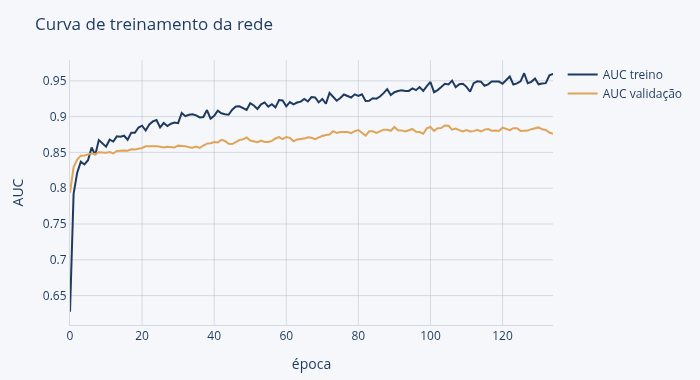

In [4]:
prep_nn = preproc.fit(X_tr)  # ajustado só no treino
X_tr_m = prep_nn.transform(X_tr).astype('float32')
X_te_m = prep_nn.transform(X_te).astype('float32')

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
i_fit, i_val = next(gss_val.split(X_tr_m, y_tr, groups=grupos.iloc[idx_tr]))

def montar_rede(n_features):
    model = keras.Sequential([
        keras.layers.Input(shape=(n_features,)),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dropout(0.30),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dropout(0.15),
        keras.layers.Dense(1, activation='sigmoid'),
    ])
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='binary_crossentropy',
                  metrics=[keras.metrics.AUC(name='auc')])
    return model

nn = montar_rede(X_tr_m.shape[1])
es = keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=30,
                                   restore_best_weights=True)
hist = nn.fit(X_tr_m[i_fit], y_tr.iloc[i_fit],
              validation_data=(X_tr_m[i_val], y_tr.iloc[i_val]),
              epochs=400, batch_size=32, callbacks=[es], verbose=0)
print(f'épocas treinadas: {len(hist.history["loss"])} (early stopping)')

probas['Rede Neural (Keras)'] = nn.predict(X_te_m, verbose=0).ravel()
resultados.append(avaliar('Rede Neural (Keras)', y_te, probas['Rede Neural (Keras)']))

fig = go.Figure()
for chave, rotulo, cor in [('auc', 'AUC treino', AZUL), ('val_auc', 'AUC validação', AMBAR)]:
    fig.add_scatter(y=hist.history[chave], mode='lines', name=rotulo, line=dict(color=cor, width=2),
                    hovertemplate='%{y:.3f}<extra></extra>')
fig.update_layout(title='Curva de treinamento da rede', xaxis_title='época', yaxis_title='AUC',
                  hovermode='x unified')
aplicar_marca(fig, 380).show()

## 4. Comparação, matriz de confusão e subgrupo crítico

                     acuracia  precisao  recall     f1  roc_auc  pr_auc
modelo                                                                 
Regressão Logística     0.732     0.758   0.713  0.735    0.843   0.860
RandomForest            0.782     0.772   0.824  0.797    0.871   0.858
Rede Neural (Keras)     0.743     0.745   0.772  0.758    0.836   0.833

Campeão por ROC-AUC no teste: RandomForest


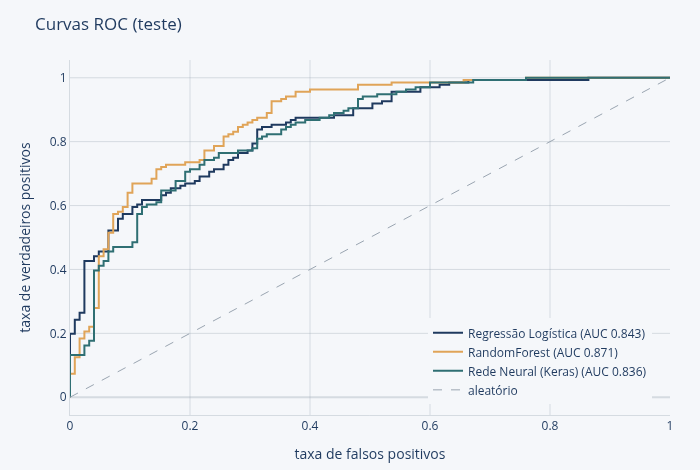

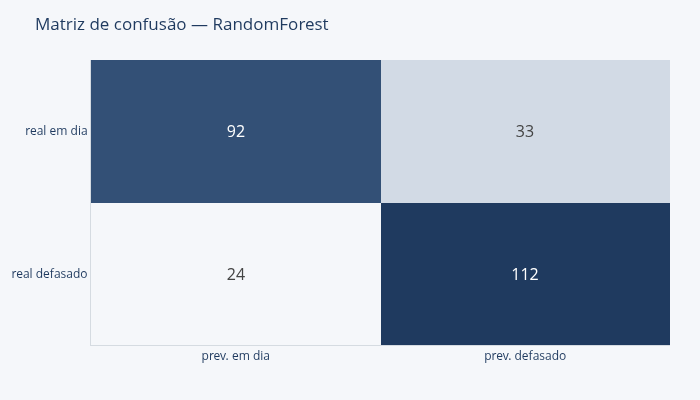

In [5]:
tab = pd.DataFrame(resultados).set_index('modelo').round(3)
print(tab.to_string())

campeao = tab['roc_auc'].idxmax()
print(f'\nCampeão por ROC-AUC no teste: {campeao}')

fig = go.Figure()
for (nome, pr), cor in zip(probas.items(), CORES_MARCA):
    fpr, tpr, _ = roc_curve(y_te, pr)
    fig.add_scatter(x=fpr, y=tpr, mode='lines', line=dict(color=cor, width=2),
                    name=f'{nome} (AUC {roc_auc_score(y_te, pr):.3f})',
                    hovertemplate='FPR %{x:.3f} · TPR %{y:.3f}<extra>' + nome + '</extra>')
fig.add_scatter(x=[0, 1], y=[0, 1], mode='lines', name='aleatório', hoverinfo='skip',
                line=dict(color=CINZA, width=1, dash='dash'))
fig.update_layout(title='Curvas ROC (teste)', xaxis_title='taxa de falsos positivos',
                  yaxis_title='taxa de verdadeiros positivos',
                  legend=dict(yanchor='bottom', y=0.03, xanchor='right', x=0.97))
aplicar_marca(fig, 470).show()

# A matriz usa rampa sequencial de um matiz só — aqui a cor codifica magnitude, não identidade — indo do
# off-white da marca ao azul profundo.
cm = confusion_matrix(y_te, (probas[campeao] >= 0.5).astype(int))
fig = go.Figure(go.Heatmap(z=cm, colorscale=ESCALA_MATRIZ, showscale=False,
                           x=['prev. em dia', 'prev. defasado'],
                           y=['real em dia', 'real defasado'],
                           text=cm, texttemplate='%{text}', textfont_size=16,
                           hovertemplate='%{y} · %{x}: %{z} casos<extra></extra>'))
fig.update_layout(title=f'Matriz de confusão — {campeao}')
fig.update_yaxes(autorange='reversed')
aplicar_marca(fig, 400).show()

In [6]:
# Subgrupo crítico: aluno EM DIA no ano t (defasagem >= 0) que se defasa em t+1.
# É o caso que o alerta precoce existe para pegar.
mask_te = (X_te['defasagem'] >= 0).values
sub_y = y_te[mask_te]
print(f'alunos em dia no ano t (teste): {mask_te.sum()} | viram defasados em t+1: {sub_y.sum()}')
for nome, pr in probas.items():
    pred = (pr[mask_te] >= 0.5).astype(int)
    rec = recall_score(sub_y, pred) if sub_y.sum() else float('nan')
    prec = precision_score(sub_y, pred) if pred.sum() else float('nan')
    print(f'{nome:24s} recall novos defasados: {rec:.2f} | precisão no subgrupo: {prec:.2f}')

alunos em dia no ano t (teste): 87 | viram defasados em t+1: 22
Regressão Logística      recall novos defasados: 0.27 | precisão no subgrupo: 0.46
RandomForest             recall novos defasados: 0.73 | precisão no subgrupo: 0.55
Rede Neural (Keras)      recall novos defasados: 0.59 | precisão no subgrupo: 0.50


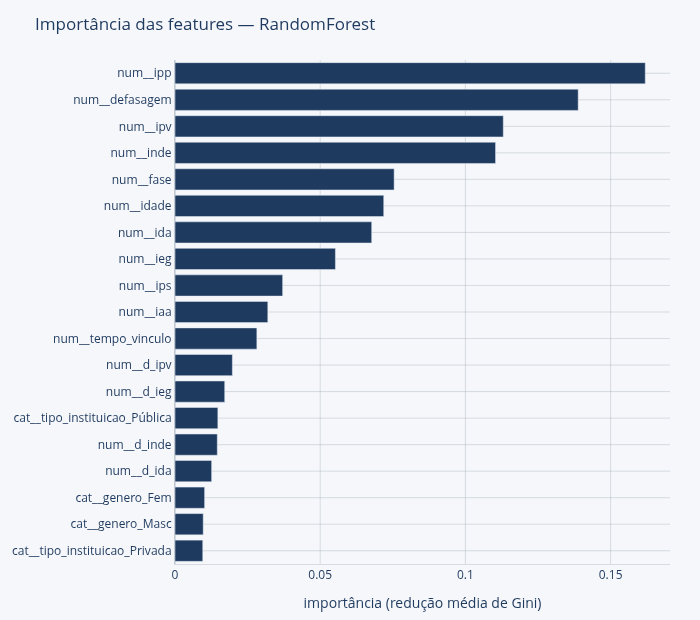

num__ipp          0.162
num__defasagem    0.139
num__ipv          0.113
num__inde         0.110
num__fase         0.075
num__idade        0.072
num__ida          0.068
num__ieg          0.055
dtype: float64


In [7]:
# Importância de features (RandomForest)
nomes = rf.named_steps['prep'].get_feature_names_out()
imp = pd.Series(rf.named_steps['clf'].feature_importances_, index=nomes) \
        .sort_values(ascending=True)
fig = go.Figure(go.Bar(y=imp.index, x=imp.to_numpy(), orientation='h', marker_color=AZUL,
                       hovertemplate='%{y}: %{x:.3f}<extra></extra>'))
fig.update_layout(title='Importância das features — RandomForest',
                  xaxis_title='importância (redução média de Gini)', showlegend=False)
aplicar_marca(fig, 620).show()
print(imp.sort_values(ascending=False).round(3).head(8))

## 5. Validações de robustez: baseline de persistência e validação temporal

Duas checagens que as métricas da seção 4 não cobrem. O **baseline de persistência** responde se o modelo
agrega algo além do óbvio: a regra "quem está defasado hoje continua defasado no ano que vem" não exige
modelo algum e já acerta bastante — o campeão precisa superá-la com folga para justificar a própria
existência. A **validação temporal** responde se o aprendizado generaliza entre anos: o split por aluno da
seção 1 impede a memorização de alunos, mas não impede que o modelo aprenda padrões específicos de um ano;
treinar apenas nas transições 2022→2023 e testar nas de 2023→2024 reproduz o cenário real de uso — prever o
futuro com dados do passado.

In [8]:
# Regra de persistência: "quem está defasado em t segue defasado em t+1". Como predição binária usa-se
# defasagem < 0; como score contínuo para ROC-AUC/PR-AUC, -defasagem (quanto mais negativa a defasagem hoje,
# maior o risco amanhã). Se o campeão não superar esta regra com folga, o pipeline inteiro seria
# dispensável — a regra não exige modelo algum.
persist = avaliar('Persistência (defasagem<0 em t)', y_te, (X_te['defasagem'] < 0).astype(float).to_numpy())
persist['roc_auc'] = roc_auc_score(y_te, -X_te['defasagem'])
persist['pr_auc'] = average_precision_score(y_te, -X_te['defasagem'])

pd.DataFrame([persist, avaliar('RandomForest (campeão)', y_te, probas['RandomForest'])]) \
  .set_index('modelo').round(3)

,acuracia,precisao,recall,f1,roc_auc,pr_auc
modelo,,,,,,
Persistência (defasagem<0 em t),0.686,0.655,0.838,0.735,0.744,0.714
RandomForest (campeão),0.782,0.772,0.824,0.797,0.871,0.858


In [9]:
from sklearn.base import clone

# Treina o mesmo pipeline apenas nas transições de t=2022 (alvo em 2023) e testa nas de t=2023 (alvo em 2024).
# O clone é necessário para não reajustar o preproc já compartilhado pelos modelos das seções 2-3. Nota:
# em t=2022 as tendências d_* são 100% NaN (não existe 2021), então este treino não enxerga essas
# features — a comparação é conservadora contra o modelo.
tr_t, te_t = base[base['ano'] == 2022], base[base['ano'] == 2023]
print(f"treino t=2022: {len(tr_t)} ({tr_t['alvo'].mean()*100:.1f}% pos) | "
      f"teste t=2023: {len(te_t)} ({te_t['alvo'].mean()*100:.1f}% pos)")

rf_temporal = Pipeline([('prep', clone(preproc)),
                        ('clf', RandomForestClassifier(n_estimators=400, min_samples_leaf=3,
                                                       class_weight='balanced',
                                                       random_state=SEED, n_jobs=-1))])
rf_temporal.fit(tr_t[FEATURES], tr_t['alvo'])
proba_temporal = rf_temporal.predict_proba(te_t[FEATURES])[:, 1]

persist_t = avaliar('Persistência (defasagem<0 em t)', te_t['alvo'],
                    (te_t['defasagem'] < 0).astype(float).to_numpy())
persist_t['roc_auc'] = roc_auc_score(te_t['alvo'], -te_t['defasagem'])
persist_t['pr_auc'] = average_precision_score(te_t['alvo'], -te_t['defasagem'])

pd.DataFrame([persist_t, avaliar('RF treinado só em 2022→2023', te_t['alvo'], proba_temporal)]) \
  .set_index('modelo').round(3)

treino t=2022: 600 (61.0% pos) | teste t=2023: 690 (44.2% pos)


,acuracia,precisao,recall,f1,roc_auc,pr_auc
modelo,,,,,,
Persistência (defasagem<0 em t),0.633,0.567,0.725,0.636,0.702,0.631
RF treinado só em 2022→2023,0.759,0.836,0.567,0.676,0.865,0.829


## 6. Exportação dos artefatos para o dashboard

In [10]:
import os
os.makedirs('../models', exist_ok=True)

joblib.dump(prep_nn, '../models/risk_preprocessor.pkl')       # pré-processador ajustado
nn.save('../models/risk_nn.keras')                            # rede neural
joblib.dump(rf, '../models/risk_rf.pkl')                      # pipeline RF completo
joblib.dump(logit, '../models/risk_logit.pkl')                # baseline

meta = {
    'desenho': 'early-warning t->t+1: prever defasagem (defasagem<0) no ano seguinte',
    'campeao': campeao,
    'metricas_teste': {k: {m: round(float(v), 4) for m, v in avaliar(k, y_te, pr).items()
                           if m != 'modelo'} for k, pr in probas.items()},
    'features_num': FEATURES_NUM,
    'features_cat': FEATURES_CAT,
    'limiar_padrao': 0.5,
    'n_treino': int(len(X_tr)), 'n_teste': int(len(X_te)),
}
with open('../models/risk_metadata.json', 'w') as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)
print('artefatos salvos em ../models/:', sorted(os.listdir('../models')))

artefatos salvos em ../models/: ['.gitkeep', 'risk_logit.pkl', 'risk_metadata.json', 'risk_nn.keras', 'risk_preprocessor.pkl', 'risk_rf.pkl']


## Conclusões

| Modelo | Acurácia | F1 | ROC-AUC | Recall novos defasados* |
|---|---|---|---|---|
| Regressão Logística (baseline) | 0,736 | 0,742 | 0,842 | 0,27 |
| **RandomForest (campeão)** | **0,782** | **0,797** | **0,871** | **0,73** |
| Rede Neural (Keras) | 0,751 | 0,760 | 0,850 | 0,55 |

\* recall no subgrupo crítico do teste: alunos **em dia** no ano t que se defasaram em t+1
(22 casos) — exatamente quem um alerta precoce existe para pegar.

**Leituras principais:**
- O **RandomForest** é o campeão em todas as métricas agregadas e, sobretudo, no
  subgrupo crítico: pega **73% dos alunos que vão se defasar** estando hoje em dia,
  contra 27% do baseline linear. É o modelo servido no dashboard (`risk_rf.pkl`).
- A **rede neural** (2 camadas ocultas, dropout, early stopping por AUC em validação
  separada por aluno) fica próxima (ROC-AUC 0,850) e cumpre o requisito de Deep
  Learning da Fase 5; com ~1.300 exemplos, o teto de uma MLP contra árvores é esperado.
- Features mais importantes (RF): **IPP, defasagem atual, IPV, INDE** — coerente com os
  sinais univariados da EDA (P9) e com a semântica do problema: o estado psicopedagógico
  e a proximidade da fronteira de defasagem hoje antecipam o risco de amanhã.
- Sem vazamento: alvo em t+1, split por aluno (treino e teste disjuntos em `id_aluno`),
  imputação e escala ajustadas só no treino.

**Validações de robustez (seção 5):**
- O campeão supera com folga o baseline de persistência no mesmo teste (ROC-AUC 0,871
  contra 0,744; acurácia 0,782 contra 0,686) — o modelo agrega sinal real além da regra
  trivial, que não exige modelo algum.
- Na validação temporal (treino só em 2022→2023, teste em 2023→2024) o poder de
  **ordenação** se mantém quase intacto (ROC-AUC 0,862 contra 0,871 do split aleatório) —
  sinal de que o modelo aprendeu padrões que valem entre anos, não peculiaridades de um
  ano. Já o limiar fixo de 0,5 descalibra: o recall cai a 0,56, porque a prevalência do
  alvo despenca entre treino e teste (61% em 2022 → 44% em 2023) e o treino de 2022 não
  tem as tendências d\_\* (não existe 2021). A recomendação operacional que segue disso é usar o modelo como **ranking
  de priorização** — atender os top-N alunos de maior probabilidade conforme a capacidade
  da equipe — em vez de aplicar corte fixo; o limiar ajustável do dashboard existe para isso.

**Artefatos exportados** (`models/`): `risk_rf.pkl` (campeão), `risk_nn.keras` +
`risk_preprocessor.pkl`, `risk_logit.pkl`, `risk_metadata.json` (features, métricas,
limiar) — consumidos pelo dashboard Streamlit.